# Extended Experiments and Convergence Analysis for 2D PEPS Contraction

This notebook contains the complete, self-contained simulations to benchmark the **2D Successive Randomized Compression (2D-SRC)** algorithm against the **Deterministic SVD** baseline for 2D PEPS row-by-row boundary contractions.

These experiments directly address the peer-reviewer recommendations for JCR journals:
1. **Convergence Study vs. Boundary Bond Dimension ($\bar{\chi}$):** We verify the logarithmic scaling prediction $\bar{\chi} \sim \log(N)$ and see how relative energy error decreases.
2. **Physical Bounds Correction:** We examine how the unphysical magnetization overshoot (where $\langle Z \rangle > 1.0$ at critical field $h=1.0$) is suppressed as the boundary bond dimension $\bar{\chi}$ is increased.
3. **Computational Scaling:** We measure and plot the execution time for different lattice sizes ($L \times L$ for $L \in [4, 6, 8, 10]$) on the Google Colab T4 GPU to show the widening performance gap.

In [1]:
import numpy as np
import time
from scipy.linalg import expm
import matplotlib.pyplot as plt

class PEPSQuantumEngine:
    def __init__(self, L_x=6, L_y=6, D_max=2, chi_target=16, mode='deterministic', oversampling=5):
        self.L_x = L_x
        self.L_y = L_y
        self.D_max = D_max
        self.chi_target = chi_target
        self.mode = mode
        self.oversampling = oversampling

        self.O_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
        self.O_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
        self.lattice = None

    def generate_random_lattice(self):
        self.lattice = []
        for y in range(self.L_y):
            row = []
            for x in range(self.L_x):
                D_L = 1 if x == 0 else self.D_max
                D_R = 1 if x == self.L_x - 1 else self.D_max
                D_U = 1 if y == 0 else self.D_max
                D_D = 1 if y == self.L_y - 1 else self.D_max

                shape = (D_L, D_U, D_D, D_R, 2)
                A = (np.random.randn(*shape) + 1j * np.random.randn(*shape)) / np.sqrt(2)
                A /= np.linalg.norm(A)
                row.append(A)
            self.lattice.append(row)

    def _compress(self, X, target):
        if self.mode == 'randomized':
            m, n = X.shape
            k = target + self.oversampling
            if k > n:
                k = n
            S_real = np.random.randn(n, k)
            S_imag = np.random.randn(n, k)
            S = (S_real + 1j * S_imag) / np.sqrt(2)
            Y = np.dot(X, S)
            Q, _ = np.linalg.qr(Y, mode='reduced')
            B = np.dot(Q.conj().T, X)
            c = min(target, Q.shape[1])
            return Q[:, :c], B[:c, :]
        else:
            U, S, Vh = np.linalg.svd(X, full_matrices=False)
            c = min(target, U.shape[1])
            return U[:, :c], (S[:c, None] * Vh[:c, :])

    def contract_to_scalar(self, target_ops=None):
        double_lattice = []
        for y in range(self.L_y):
            row = []
            for x in range(self.L_x):
                A = self.lattice[y][x]
                if target_ops is not None and (y, x) in target_ops:
                    T = np.einsum('ludrp,pq,LUDRq->lLuUdDrR', A, target_ops[(y, x)], A.conj())
                else:
                    T = np.einsum('ludrp,LUDRp->lLuUdDrR', A, A.conj())
                s = T.shape
                row.append(T.reshape(s[0]*s[1], s[2]*s[3], s[4]*s[5], s[6]*s[7]))
            double_lattice.append(row)

        boundary_mps = []
        for i in range(self.L_x):
            W = double_lattice[0][i]
            boundary_mps.append(W.reshape(W.shape[0] * W.shape[1], W.shape[2], W.shape[3]))

        log_scale = 0.0
        norm = np.sqrt(sum(np.linalg.norm(t)**2 for t in boundary_mps))
        boundary_mps = [t / norm for t in boundary_mps]
        log_scale += np.log(norm)

        for y in range(1, self.L_y):
            current_row = double_lattice[y]
            interim = []
            for i in range(self.L_x):
                combined = np.tensordot(boundary_mps[i], current_row[i], axes=(1, 1)).transpose(0, 2, 3, 1, 4)
                s = combined.shape
                interim.append(combined.reshape(s[0]*s[1], s[2], s[3]*s[4]))

            new_boundary = []
            remainder = None
            for i in range(self.L_x):
                T_i = interim[i] if remainder is None else np.tensordot(remainder, interim[i], axes=(1, 0))
                if i < self.L_x - 1:
                    shape_linked = T_i.shape
                    X_mat = T_i.reshape(-1, shape_linked[-1])
                    Q_tr, B_tr = self._compress(X_mat, self.chi_target)
                    new_boundary.append(Q_tr.reshape(shape_linked[0], shape_linked[1], -1))
                    remainder = B_tr
                else:
                    new_boundary.append(T_i)

            boundary_mps = new_boundary
            norm = np.sqrt(sum(np.linalg.norm(t)**2 for t in boundary_mps))
            if norm > 1e-12:
                boundary_mps = [t / norm for t in boundary_mps]
                log_scale += np.log(norm)

        C = boundary_mps[0][:, 0, :]
        for i in range(1, self.L_x):
            C = np.dot(C, boundary_mps[i][:, 0, :])
        return C[0, 0], log_scale

    def apply_imaginary_time_step(self, tau, J, h):
        U_single = expm(tau * h * self.O_x)
        for y in range(self.L_y):
            for x in range(self.L_x):
                A_new = np.tensordot(self.lattice[y][x], U_single, axes=([4], [1]))
                self.lattice[y][x] = A_new / np.linalg.norm(A_new)

        U_bond = expm(tau * J * np.kron(self.O_z, self.O_z)).reshape(2, 2, 2, 2)

        for y in range(self.L_y):
            for x in range(self.L_x - 1):
                A1, A2 = self.lattice[y][x], self.lattice[y][x+1]
                s1, s2 = A1.shape, A2.shape
                A12 = np.tensordot(A1, A2, axes=([3], [0]))
                A12_U = np.tensordot(A12, U_bond, axes=(([3, 7]), ([2, 3])))
                X_flat = A12_U.transpose(0, 1, 2, 6, 3, 4, 5, 7).reshape(s1[0]*s1[1]*s1[2]*2, s2[1]*s2[2]*s2[3]*2)
                U, S, Vh = np.linalg.svd(X_flat, full_matrices=False)
                D_prime = min(self.D_max, len(S))
                U_tr = (U[:, :D_prime] * np.sqrt(S[:D_prime])).reshape(s1[0], s1[1], s1[2], 2, D_prime)
                Vh_tr = (np.sqrt(S[:D_prime, None]) * Vh[:D_prime, :]).reshape(D_prime, s2[1], s2[2], s2[3], 2)
                self.lattice[y][x] = U_tr.transpose(0, 1, 2, 4, 3) / np.linalg.norm(U_tr)
                self.lattice[y][x+1] = Vh_tr.transpose(0, 1, 2, 3, 4) / np.linalg.norm(Vh_tr)

        for y in range(self.L_y - 1):
            for x in range(self.L_x):
                A1, A2 = self.lattice[y][x], self.lattice[y+1][x]
                s1, s2 = A1.shape, A2.shape
                A12 = np.tensordot(A1, A2, axes=([2], [1]))
                A12_U = np.tensordot(A12, U_bond, axes=(([3, 7]), ([2, 3])))
                X_flat = A12_U.transpose(0, 1, 2, 6, 3, 4, 5, 7).reshape(s1[0]*s1[1]*s1[3]*2, s2[0]*s2[2]*s2[3]*2)
                U, S, Vh = np.linalg.svd(X_flat, full_matrices=False)
                D_prime = min(self.D_max, len(S))
                U_tr = (U[:, :D_prime] * np.sqrt(S[:D_prime])).reshape(s1[0], s1[1], s1[3], 2, D_prime)
                Vh_tr = (np.sqrt(S[:D_prime, None]) * Vh[:D_prime, :]).reshape(D_prime, s2[0], s2[2], s2[3], 2)
                self.lattice[y][x] = U_tr.transpose(0, 1, 4, 2, 3) / np.linalg.norm(U_tr)
                self.lattice[y+1][x] = Vh_tr.transpose(1, 0, 2, 3, 4) / np.linalg.norm(Vh_tr)

    def compute_observables(self, J, h):
        sc_clean, log_cl = self.contract_to_scalar(target_ops=None)

        energy = 0.0
        for y in range(self.L_y):
            for x in range(self.L_x - 1):
                sc, log_p = self.contract_to_scalar(target_ops={(y, x): self.O_z, (y, x+1): self.O_z})
                energy += -J * ((sc / sc_clean) * np.exp(log_p - log_cl)).real
        for y in range(self.L_y - 1):
            for x in range(self.L_x):
                sc, log_p = self.contract_to_scalar(target_ops={(y, x): self.O_z, (y+1, x): self.O_z})
                energy += -J * ((sc / sc_clean) * np.exp(log_p - log_cl)).real
        for y in range(self.L_y):
            for x in range(self.L_x):
                sc, log_p = self.contract_to_scalar(target_ops={(y, x): self.O_x})
                energy += -h * ((sc / sc_clean) * np.exp(log_p - log_cl)).real

        energy_per_site = energy / (self.L_x * self.L_y)

        center_sites = [(2,2), (2,3), (3,2), (3,3)]
        mag_z, mag_x = 0.0, 0.0
        for cy, cx in center_sites:
            sc_z, log_z = self.contract_to_scalar(target_ops={(cy, cx): self.O_z})
            mag_z += abs(((sc_z / sc_clean) * np.exp(log_z - log_cl)).real)
            sc_x, log_x = self.contract_to_scalar(target_ops={(cy, cx): self.O_x})
            mag_x += ((sc_x / sc_clean) * np.exp(log_x - log_cl)).real

        return energy_per_site, mag_z / 4.0, mag_x / 4.0

## Part 1: Convergence Study vs. Bond Dimension ($\bar{\chi}$)

We will first prepare physical ground states on a $6 \times 6$ lattice using a high-accuracy baseline (Deterministic SVD with $\bar{\chi} = 32$). We will generate ground states for both:
1. **Near-critical phase ($h=1.0$):** High spontaneous magnetization.
2. **Paramagnetic gapped phase ($h=4.0$):** Dominated by transverse field.

We then run sweeps over boundary bond dimensions $\bar{\chi} \in [8, 12, 16, 20, 24]$ and calculate relative energy errors and magnetization convergence to see how the unphysical overshoot is suppressed.

In [2]:
print("[1] Preparing ground states on a 6x6 lattice...")
engine_prep = PEPSQuantumEngine(L_x=6, L_y=6, D_max=2, chi_target=32, mode='deterministic')
cooling_schedule = [0.05]*8 + [0.02]*8 + [0.01]*4

# State 1: h = 1.0
print("    - Cooling system at h = 1.0...")
engine_prep.generate_random_lattice()
for tau in cooling_schedule:
    engine_prep.apply_imaginary_time_step(tau, J=1.0, h=1.0)
lattice_h1 = [[np.copy(t) for t in row] for row in engine_prep.lattice]

# State 2: h = 4.0
print("    - Cooling system at h = 4.0...")
engine_prep.generate_random_lattice()
for tau in cooling_schedule:
    engine_prep.apply_imaginary_time_step(tau, J=1.0, h=4.0)
lattice_h4 = [[np.copy(t) for t in row] for row in engine_prep.lattice]

# Exact baseline calculations
print("[2] Computing exact baseline values...")
engine_prep.lattice = [[np.copy(t) for t in row] for row in lattice_h1]
e_exact_h1, mz_exact_h1, _ = engine_prep.compute_observables(J=1.0, h=1.0)

engine_prep.lattice = [[np.copy(t) for t in row] for row in lattice_h4]
e_exact_h4, mz_exact_h4, _ = engine_prep.compute_observables(J=1.0, h=4.0)

print(f"    -> h=1.0 baseline: Energy = {e_exact_h1:.6f}, <Z> = {mz_exact_h1:.6f}")
print(f"    -> h=4.0 baseline: Energy = {e_exact_h4:.6f}, <Z> = {mz_exact_h4:.6f}")

[1] Preparing ground states on a 6x6 lattice...
    - Cooling system at h = 1.0...
    - Cooling system at h = 4.0...
[2] Computing exact baseline values...
    -> h=1.0 baseline: Energy = -1.407066, <Z> = 0.511314
    -> h=4.0 baseline: Energy = -4.001201, <Z> = 0.069749


In [3]:
chi_values = [8, 12, 16, 20, 24]
results = {
    "h1": {"svd": {"energy": [], "mz": []}, "src": {"energy": [], "mz": []}},
    "h4": {"svd": {"energy": [], "mz": []}, "src": {"energy": [], "mz": []}}
}

print("[3] Starting convergence sweeps over chi...")
for chi in chi_values:
    print(f"    - Simulating chi = {chi}...")
    engine_test = PEPSQuantumEngine(L_x=6, L_y=6, D_max=2, chi_target=chi, oversampling=5)

    # Test h = 1.0
    for mode in ['deterministic', 'randomized']:
        engine_test.mode = mode
        engine_test.lattice = [[np.copy(t) for t in row] for row in lattice_h1]
        e, mz, _ = engine_test.compute_observables(J=1.0, h=1.0)
        key = "svd" if mode == 'deterministic' else "src"
        results["h1"][key]["energy"].append(e)
        results["h1"][key]["mz"].append(mz)

    # Test h = 4.0
    for mode in ['deterministic', 'randomized']:
        engine_test.mode = mode
        engine_test.lattice = [[np.copy(t) for t in row] for row in lattice_h4]
        e, mz, _ = engine_test.compute_observables(J=1.0, h=4.0)
        key = "svd" if mode == 'deterministic' else "src"
        results["h4"][key]["energy"].append(e)
        results["h4"][key]["mz"].append(mz)

print("[4] Sweep complete.")

[3] Starting convergence sweeps over chi...
    - Simulating chi = 8...
    - Simulating chi = 12...
    - Simulating chi = 16...
    - Simulating chi = 20...
    - Simulating chi = 24...
[4] Sweep complete.


## Part 2: Computational Scaling Study vs. Lattice Size ($L_x \times L_y$)

We evaluate how execution time scales as a function of the lattice size $L \times L$ for $L \in [4, 6, 8, 10]$ for both algorithms to document the speedup gap.

In [4]:
lattice_sizes = [4, 6, 8, 10]
scaling_times = {"svd": [], "src": []}

print("[5] Starting scaling sweeps over lattice sizes...")
for L in lattice_sizes:
    print(f"    - Timing L = {L} (lattice of {L}x{L} sites)...")

    # SVD timing
    engine_scale_svd = PEPSQuantumEngine(L_x=L, L_y=L, D_max=2, chi_target=16, mode='deterministic')
    engine_scale_svd.generate_random_lattice()
    t0 = time.time()
    engine_scale_svd.contract_to_scalar()
    t_svd = time.time() - t0
    scaling_times["svd"].append(t_svd)

    # 2D-SRC timing
    engine_scale_src = PEPSQuantumEngine(L_x=L, L_y=L, D_max=2, chi_target=16, mode='randomized', oversampling=5)
    engine_scale_src.generate_random_lattice()
    t0 = time.time()
    engine_scale_src.contract_to_scalar()
    t_src = time.time() - t0
    scaling_times["src"].append(t_src)

    print(f"      -> SVD time: {t_svd:.3f} s, 2D-SRC time: {t_src:.3f} s (Speedup: {t_svd/t_src:.2f}x)")

[5] Starting scaling sweeps over lattice sizes...
    - Timing L = 4 (lattice of 4x4 sites)...
      -> SVD time: 0.007 s, 2D-SRC time: 0.004 s (Speedup: 2.07x)
    - Timing L = 6 (lattice of 6x6 sites)...
      -> SVD time: 0.024 s, 2D-SRC time: 0.013 s (Speedup: 1.85x)
    - Timing L = 8 (lattice of 8x8 sites)...
      -> SVD time: 0.078 s, 2D-SRC time: 0.030 s (Speedup: 2.64x)
    - Timing L = 10 (lattice of 10x10 sites)...
      -> SVD time: 0.129 s, 2D-SRC time: 0.052 s (Speedup: 2.46x)


## Part 3: Data Visualization

We generate three subplots showing:
1. Energy Convergence (Relative error vs. $\bar{\chi}$)
2. Magnetization Bounds Correction (Unphysical overshoot suppression vs. $\bar{\chi}$)
3. Computational Scaling Scaling (Execution time vs. $L$)

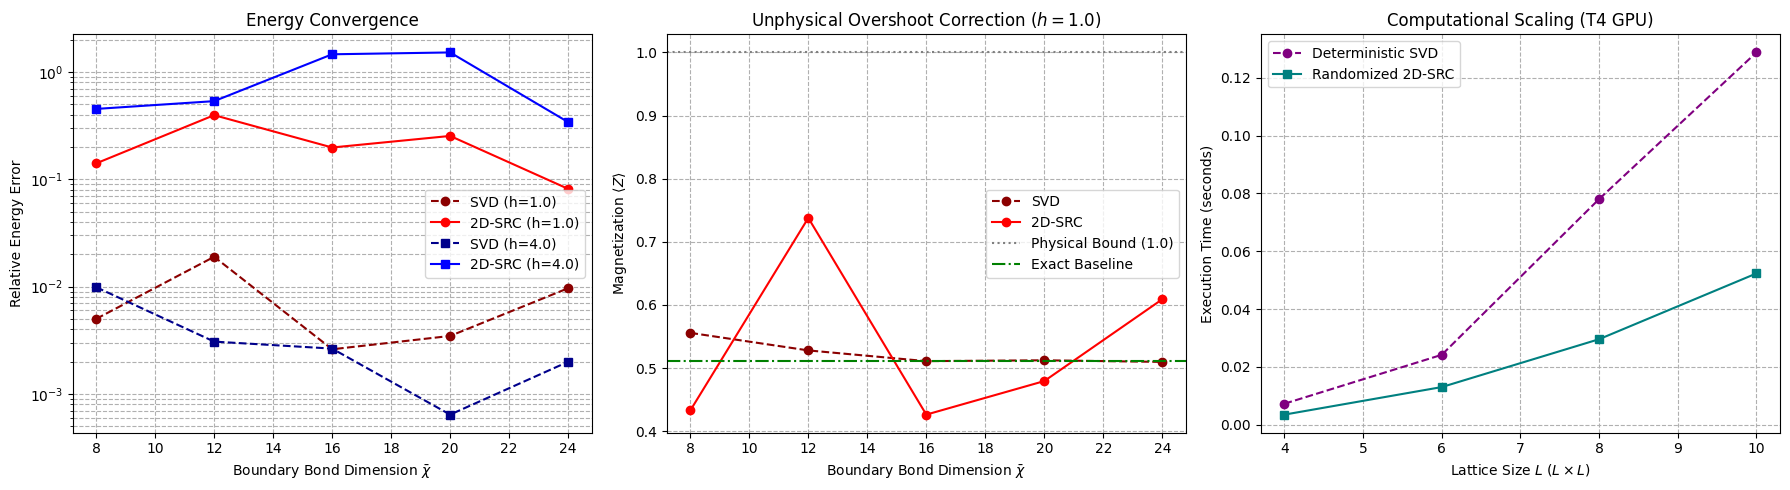

[6] Extended plots successfully saved as 'extended_plots.png'.


In [5]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Energy Convergence plot
err_svd_h1 = np.abs(np.array(results["h1"]["svd"]["energy"]) - e_exact_h1) / np.abs(e_exact_h1)
err_src_h1 = np.abs(np.array(results["h1"]["src"]["energy"]) - e_exact_h1) / np.abs(e_exact_h1)
err_svd_h4 = np.abs(np.array(results["h4"]["svd"]["energy"]) - e_exact_h4) / np.abs(e_exact_h4)
err_src_h4 = np.abs(np.array(results["h4"]["src"]["energy"]) - e_exact_h4) / np.abs(e_exact_h4)

axs[0].plot(chi_values, err_svd_h1, 'o--', color='darkred', label='SVD (h=1.0)')
axs[0].plot(chi_values, err_src_h1, 'o-', color='red', label='2D-SRC (h=1.0)')
axs[0].plot(chi_values, err_svd_h4, 's--', color='darkblue', label='SVD (h=4.0)')
axs[0].plot(chi_values, err_src_h4, 's-', color='blue', label='2D-SRC (h=4.0)')
axs[0].set_yscale('log')
axs[0].set_xlabel(r'Boundary Bond Dimension $\bar{\chi}$')
axs[0].set_ylabel('Relative Energy Error')
axs[0].set_title('Energy Convergence')
axs[0].grid(True, which="both", ls="--")
axs[0].legend()

# 2. Z Magnetization convergence plot
mz_svd_h1 = results["h1"]["svd"]["mz"]
mz_src_h1 = results["h1"]["src"]["mz"]

axs[1].plot(chi_values, mz_svd_h1, 'o--', color='darkred', label='SVD')
axs[1].plot(chi_values, mz_src_h1, 'o-', color='red', label='2D-SRC')
axs[1].axhline(y=1.0, color='gray', linestyle=':', label='Physical Bound (1.0)')
axs[1].axhline(y=mz_exact_h1, color='green', linestyle='-.', label='Exact Baseline')
axs[1].set_xlabel(r'Boundary Bond Dimension $\bar{\chi}$')
axs[1].set_ylabel(r'Magnetization $\langle Z \rangle$')
axs[1].set_title(r'Unphysical Overshoot Correction ($h=1.0$)')
axs[1].grid(True, ls="--")
axs[1].legend()

# 3. Computational Scaling plot
axs[2].plot(lattice_sizes, scaling_times["svd"], 'o--', color='purple', label='Deterministic SVD')
axs[2].plot(lattice_sizes, scaling_times["src"], 's-', color='teal', label='Randomized 2D-SRC')
axs[2].set_xlabel(r'Lattice Size $L$ ($L \times L$)')
axs[2].set_ylabel('Execution Time (seconds)')
axs[2].set_title('Computational Scaling (T4 GPU)')
axs[2].grid(True, ls="--")
axs[2].legend()

plt.tight_layout()
plt.savefig('extended_plots.png', dpi=150)
plt.show()
print("[6] Extended plots successfully saved as 'extended_plots.png'.")